# Pipeline for the anomaly detection on the SKAB using Isolation Forest

Details regarding the SKAB one can find in the [SKAB repository](https://github.com/waico/SKAB).

## Libraries importing

In [1]:
# libraries importing
import sys
import warnings

import pandas as pd

sys.path.append("..")
from core.Isolation_Forest import Isolation_Forest
from core.metrics import chp_score
from core.utils import load_preprocess_skab, plot_results

warnings.filterwarnings("ignore", category=UserWarning)

## Data

In [2]:
Xy_traintest_list = load_preprocess_skab()

## Method

### Method initialization

In [3]:
# hyperparameters selection
random_state = 0
n_jobs = -1
contamination = 0.0005
PARAMS = [random_state, n_jobs, contamination]

In [4]:
# model defining
model = Isolation_Forest(PARAMS)

### Method fitting and applying

In [5]:
# inference
predicted_outlier, predicted_cp = [], []
true_outlier, true_cp = [], []
all_scores = []
for X_train, X_test, y_train, y_test in Xy_traintest_list:
    # classifier fitting
    model.fit(X_train)
    raw_scores = pd.Series(
        -model.model.decision_function(X_test),
        index=X_test.index,
    )
    all_scores.append(raw_scores)

    # results predicting
    prediction = (
        pd.Series(
            model.predict(X_test) * -1,
            index=X_test.index,
        )
        .rolling(3)
        .median()
        .fillna(0)
        .replace(-1, 0)
    )

    # predicted outliers saving
    predicted_outlier.append(prediction)

    # predicted CPs saving
    prediction_cp = prediction.rolling(30).max().fillna(0).diff().abs()
    prediction_cp.iloc[0] = prediction.iloc[0]
    predicted_cp.append(prediction_cp)

    true_outlier.append(y_test["anomaly"])
    true_cp.append(y_test["changepoint"])

### Results visualization

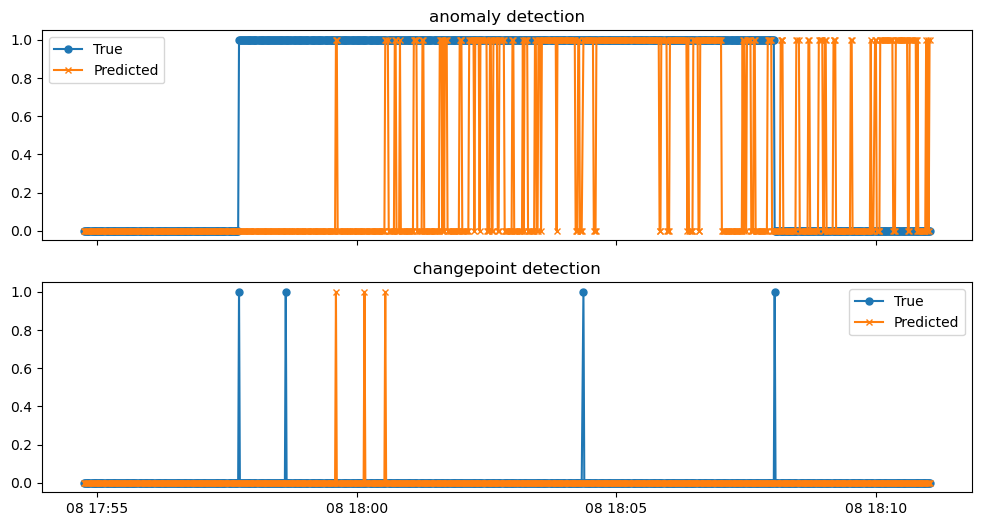

In [6]:
# [donotremove]
plot_results(
    (true_outlier[1], predicted_outlier[1]),
    (true_cp[1], predicted_cp[1]),
)

Zapisano ROC: images/roc_isolation_forest.png


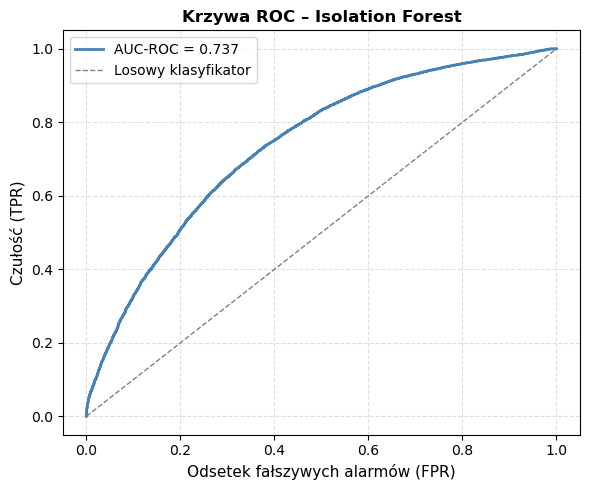

Zapisano PR: images/pr_isolation_forest.png


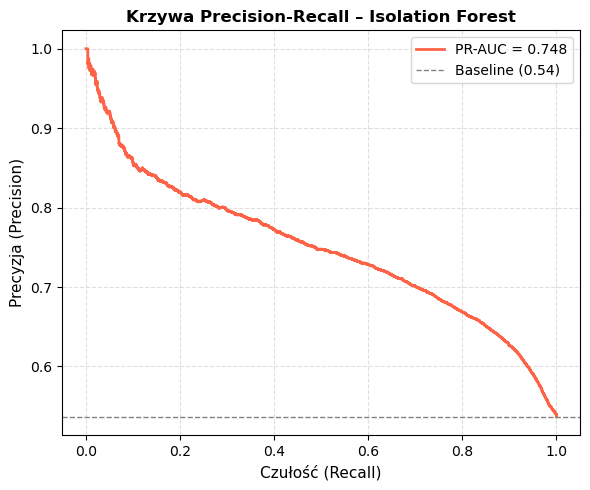


Model:    Isolation Forest
AUC-ROC:  0.7375
PR-AUC:   0.7483
MCC:      0.3571  (próg optymalny = -0.0705)

{'auc_roc': 0.7375, 'pr_auc': 0.7483, 'mcc': 0.3571}


In [7]:
import os
from core.plot_roc_pr import plot_roc_pr

os.makedirs("images", exist_ok=True)

metrics_if = plot_roc_pr(
    scores_list=all_scores,
    labels_list=true_outlier,
    model_name='Isolation Forest',
    save_roc='images/roc_isolation_forest.png',
    save_pr='images/pr_isolation_forest.png',
)
print(metrics_if)

In [8]:
from pathlib import Path
import numpy as np

Path('results').mkdir(exist_ok=True)

np.save(
    'results/scores_isolation_forest.npy',
    np.array(all_scores, dtype=object),
    allow_pickle=True
)

np.save(
    'results/labels_isolation_forest.npy',
    np.array(true_outlier, dtype=object),
    allow_pickle=True
)

print("OK: Isolation Forest zapisany")

OK: Isolation Forest zapisany


## Evaluation (metrics calculation)

In [9]:
import pickle

pickle.dump(
    predicted_outlier,
    open(
        f"../results/../results/results-{model.__class__.__name__}.pkl", "wb"
    ),
)

C:\Users\olegs\AppData\Local\Temp\ipykernel_31496\2092468838.py:3: ResourceWarning: unclosed file <_io.BufferedWriter name='../results/../results/results-Isolation_Forest.pkl'>
  pickle.dump(


### Binary classification (outlier detection) metrics

In [10]:
# [donotremove]
# binary classification metrics calculation
binary = chp_score(true_outlier, predicted_outlier, metric="binary")

False Alarm Rate 2.56 %
Missing Alarm Rate 82.89 %
F1 metric 0.29


### Changepoint detection metrics

In [11]:
# [donotremove]
# average detection delay metric calculation
add = chp_score(
    true_cp,
    predicted_cp,
    metric="average_time",
    window_width="60s",
    anomaly_window_destination="righter",
)

Amount of true anomalies 127
A number of missed CPs = 76
A number of FPs = 135
Average time 0 days 00:00:22.725490


In [12]:
# [donotremove]
# nab metric calculation
nab = chp_score(
    true_cp,
    predicted_cp,
    metric="nab",
    window_width="60s",
    anomaly_window_destination="righter",
)

Standard  -  26.16
LowFP  -  19.5
LowFN  -  30.82
